In [2]:
from sqlalchemy import create_engine
from snowflake.sqlalchemy import URL
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
import shap
import matplotlib.pyplot as plt

c:\Users\knguy139\Documents\Projects\.venv\Lib\site-packages\snowflake\connector\vendored\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.7) doesn't match a supported version!
  warnings.warn(
c:\Users\knguy139\Documents\Projects\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
engine = create_engine(URL(
    account       = "UHG-UHGDWAAS",
    user          = "KHANG.NGUYEN@UHC.COM",
    authenticator = "externalbrowser",
    role          = "AZU_SDRP_VING_PRD_DEVELOPER_ROLE",
    warehouse     = "VING_PRD_MNR_HCE_DATAINFRA_WH",
    database      = "VING_PRD_TREND_DB",
    schema        = "TMP_1M"
))

In [30]:
df_2025 = pd.read_sql("""
    select
        d.collection as hospital_group
        , a.fin_market
        , count(distinct a.case_id) as case_count
        , count(distinct case when a.initialfulladr_cases = 1 then a.case_id end) as initial_adr_cnt
        , count(distinct case when a.persistentfulladr_cases = 1 then a.case_id end) as persistent_adr_cnt
        , count(distinct case when a.p2p_full_ovtn = 1 then a.case_id end) as p2p_ovrtn_cnt
        , count(distinct case when a.appeal_ovrtn_ind = 1 then a.case_id end) as appeal_ovrtn_cnt
        , count(distinct case when a.mcr_ovtrn_ind = 1 then a.case_id end) as mcr_ovrtn_cnt
        , count(distinct case when a.icm_md_reviewed_ind = 1 then a.case_id end) as md_reviewed_cnt
    from tmp_1m.ec_avtar_25_26_3_od as a
    left join tmp_1y.tin_collection as d
        on substr(a.fa_prov_id, 2, 9) = d.tin
    where fin_brand = 'M&R'
        and (
            (ip_type in ('Medical', 'Surgical', 'Transplant')
             and to_varchar(admit_dt_act, 'MM/dd/yyyy') is not null)
            or ip_type in ('LTAC', 'SNF', 'AIR')
        )
        and loc_flag = 1
        and (
            (global_cap = 'NA' and sgr_source_name = 'COSMOS'
             and fin_product_level_3 != 'INSTITUTIONAL' and tfm_include_flag = 1)
            or (sgr_source_name = 'NICE' and nce_tadm_dec_risk_type in ('FFS', 'PHYSICIAN'))
        )
        and d.collection is not null
        and hce_admit_month between '202501' and '202512'
    group by 1,2
    having count(distinct a.case_id) >= 30
""", engine)

df_2026 = pd.read_sql("""
    select
        d.collection as hospital_group
        , a.fin_market
        , count(distinct a.case_id) as case_count
        , count(distinct case when a.initialfulladr_cases = 1 then a.case_id end) as initial_adr_cnt
        , count(distinct case when a.persistentfulladr_cases = 1 then a.case_id end) as persistent_adr_cnt
        , count(distinct case when a.p2p_full_ovtn = 1 then a.case_id end) as p2p_ovrtn_cnt
        , count(distinct case when a.appeal_ovrtn_ind = 1 then a.case_id end) as appeal_ovrtn_cnt
        , count(distinct case when a.mcr_ovtrn_ind = 1 then a.case_id end) as mcr_ovrtn_cnt
        , count(distinct case when a.icm_md_reviewed_ind = 1 then a.case_id end) as md_reviewed_cnt
        , count(distinct case when a.member_appeal_ind = 1 then a.case_id end) as member_appeal_cnt
    from tmp_1m.ec_avtar_25_26_3_od as a
    left join tmp_1y.tin_collection as d
        on substr(a.fa_prov_id, 2, 9) = d.tin
    where fin_brand = 'M&R'
        and (
            (ip_type in ('Medical', 'Surgical', 'Transplant')
             and to_varchar(admit_dt_act, 'MM/dd/yyyy') is not null)
            or ip_type in ('LTAC', 'SNF', 'AIR')
        )
        and loc_flag = 1
        and (
            (global_cap = 'NA' and sgr_source_name = 'COSMOS'
             and fin_product_level_3 != 'INSTITUTIONAL' and tfm_include_flag = 1)
            or (sgr_source_name = 'NICE' and nce_tadm_dec_risk_type in ('FFS', 'PHYSICIAN'))
        )
        and d.collection is not null
        and hce_admit_month between '202601' and '202604'
    group by 1,2
    having count(distinct a.case_id) >= 30
""", engine)

print(f"2025: {len(df_2025)} rows | 2026: {len(df_2026)} rows")

2025: 1646 rows | 2026: 1026 rows


In [ ]:
# functions kept — each called 2+ times

def mom_optimal_k(successes, trials):
    mask = (trials > 0) & (successes >= 0)
    s, n = successes[mask].values, trials[mask].values
    p = s / n
    p_bar = p.mean()
    v_obs = p.var(ddof = 1)
    n_bar = len(n) / np.sum(1.0 / n)
    v_sampling = p_bar * (1 - p_bar) / n_bar
    v_signal = v_obs - v_sampling
    if v_signal <= 0:
        return 50.0
    alpha_hat = p_bar * (p_bar * (1 - p_bar) / v_signal - 1)
    beta_hat = (1 - p_bar) * (p_bar * (1 - p_bar) / v_signal - 1)
    if alpha_hat <= 0 or beta_hat <= 0:
        return 50.0
    return alpha_hat + beta_hat


def compute_shrinkage(df, k_map):
    rate_defs = {
        "initial_adr":     ("initial_adr_cnt",    "case_count"),
        "persistent_adr":  ("persistent_adr_cnt", "case_count"),
        "p2p_overturn":    ("p2p_ovrtn_cnt",      "initial_adr_cnt"),
        "appeal_overturn": ("appeal_ovrtn_cnt",   "initial_adr_cnt"),
        "mcr_overturn":    ("mcr_ovrtn_cnt",      "initial_adr_cnt"),
        "md_review":       ("md_reviewed_cnt",    "case_count"),
    }
    if "member_appeal_cnt" in df.columns:
        rate_defs["member_appeal"] = ("member_appeal_cnt", "initial_adr_cnt")

    df_broad = df.query("case_count >= 30").copy()
    global_rates = {
        feat: df_broad[num].sum() / df_broad[denom].replace(0, np.nan).sum()
        for feat, (num, denom) in rate_defs.items()
    }

    df_out = df.query("case_count >= 30 and initial_adr_cnt >= 10").copy()

    for feat, (num, denom) in rate_defs.items():
        k_raw = k_map.get(feat, 50.0)
        k = k_raw[0] if isinstance(k_raw, tuple) else k_raw
        gr = global_rates[feat]
        df_out[f"{feat}_adj_rate"] = (df_out[num] + k * gr) / (df_out[denom] + k)

    df_out = df_out.assign(
        log_case_count = lambda x: np.log1p(x["case_count"]),
        log_initial_adr_cnt = lambda x: np.log1p(x["initial_adr_cnt"]),
    )

    rate_cols = [c for c in df_out.columns if c.endswith("_adj_rate")]
    df_out[rate_cols] = df_out[rate_cols].replace([np.inf, -np.inf], np.nan).fillna(0)

    return df_out

In [38]:
df_all = pd.concat([df_2025, df_2026], ignore_index = True).query("case_count >= 30")
df_25_broad = df_2025.query("case_count >= 30")
df_26_broad = df_2026.query("case_count >= 30")

rate_configs = {
    "initial_adr":     ("initial_adr_cnt",    "case_count"),
    "persistent_adr":  ("persistent_adr_cnt", "case_count"),
    "p2p_overturn":    ("p2p_ovrtn_cnt",      "initial_adr_cnt"),
    "appeal_overturn": ("appeal_ovrtn_cnt",   "initial_adr_cnt"),
    "mcr_overturn":    ("mcr_ovrtn_cnt",      "initial_adr_cnt"),
    "md_review":       ("md_reviewed_cnt",    "case_count"),
}

k_map = {feat: mom_optimal_k(df_all[num], df_all[denom]) for feat, (num, denom) in rate_configs.items()}
k_map["member_appeal"] = mom_optimal_k(
    df_26_broad["member_appeal_cnt"],
    df_26_broad["initial_adr_cnt"]
)

# per-year k for features with >30% divergence: mcr_overturn, appeal_overturn
k_mcr_25 = mom_optimal_k(df_25_broad["mcr_ovrtn_cnt"], df_25_broad["initial_adr_cnt"])
k_mcr_26 = mom_optimal_k(df_26_broad["mcr_ovrtn_cnt"], df_26_broad["initial_adr_cnt"])

k_appeal_25 = mom_optimal_k(df_25_broad["appeal_ovrtn_cnt"], df_25_broad["initial_adr_cnt"])
k_appeal_26 = mom_optimal_k(df_26_broad["appeal_ovrtn_cnt"], df_26_broad["initial_adr_cnt"])

# normalize: extract float if tuple (guards against validation notebook's 2-return version)
def _k_float(val):
    return val[0] if isinstance(val, tuple) else val

k_map = {feat: _k_float(v) for feat, v in k_map.items()}
k_mcr_25, k_mcr_26 = _k_float(k_mcr_25), _k_float(k_mcr_26)
k_appeal_25, k_appeal_26 = _k_float(k_appeal_25), _k_float(k_appeal_26)

print("k_map (pooled):")
for feat_name, k_val in k_map.items():
    print(f"  {feat_name:<20}: {k_val:.1f}")
print(f"\nmcr_overturn per-year: 2025 = {k_mcr_25:.1f}, 2026 = {k_mcr_26:.1f}")
print(f"appeal_overturn per-year: 2025 = {k_appeal_25:.1f}, 2026 = {k_appeal_26:.1f}")

k_map (pooled):
  initial_adr         : 8.3
  persistent_adr      : 15.1
  p2p_overturn        : 8.7
  appeal_overturn     : 1.1
  mcr_overturn        : 228.8
  md_review           : 2.0
  member_appeal       : 5.1

mcr_overturn per-year: 2025 = 149.1, 2026 = 50.0
appeal_overturn per-year: 2025 = 1.3, 2026 = 0.7


In [39]:
k_map

{'initial_adr': np.float64(8.334741837934017),
 'persistent_adr': np.float64(15.142247673268791),
 'p2p_overturn': np.float64(8.720736903387595),
 'appeal_overturn': np.float64(1.1291087867660285),
 'mcr_overturn': np.float64(228.7918901163443),
 'md_review': np.float64(2.0044795615958404),
 'member_appeal': np.float64(5.064466148157266)}

In [44]:
# k-divergence check: per-year vs pooled
rows = []
for feat, (num, denom) in rate_configs.items():
    k_25 = _k_float(mom_optimal_k(df_25_broad[num], df_25_broad[denom]))
    k_26 = _k_float(mom_optimal_k(df_26_broad[num], df_26_broad[denom]))
    k_pooled_val = k_map[feat]
    pct_diff = abs(k_25 - k_26) / k_pooled_val * 100 if k_pooled_val > 0 else 0
    rows.append({
        "feature": feat,
        "k_2025": round(k_25, 1),
        "k_2026": round(k_26, 1),
        "k_pooled": round(k_pooled_val, 1),
        "abs_diff": round(abs(k_25 - k_26), 1),
        "divergence_pct": round(pct_diff, 1),
        "use_per_year": pct_diff > 30,
    })

# member_appeal only has 2026 data
rows.append({
    "feature": "member_appeal",
    "k_2025": np.nan,
    "k_2026": round(k_map["member_appeal"], 1),
    "k_pooled": round(k_map["member_appeal"], 1),
    "abs_diff": np.nan,
    "divergence_pct": np.nan,
    "use_per_year": False,
})

df_k_compare = pd.DataFrame(rows)
print(df_k_compare.to_string(index=False))

print("\n" + "-" * 60)
per_year_feats = df_k_compare.query("use_per_year == True")["feature"].tolist()
pooled_feats = df_k_compare.query("use_per_year == False")["feature"].tolist()
print(f"→ Per-year k (>30% divergence): {per_year_feats}")
print(f"→ Pooled k: {pooled_feats}")

        feature  k_2025  k_2026  k_pooled  abs_diff  divergence_pct  use_per_year
    initial_adr     8.3     8.5       8.3       0.2             2.2         False
 persistent_adr    15.0    15.5      15.1       0.5             3.5         False
   p2p_overturn     8.3     9.4       8.7       1.1            12.2         False
appeal_overturn     1.3     0.7       1.1       0.6            55.2          True
   mcr_overturn   149.1    50.0     228.8      99.1            43.3          True
      md_review     2.1     1.9       2.0       0.1             7.2         False
  member_appeal     NaN     5.1       5.1       NaN             NaN         False

------------------------------------------------------------
→ Per-year k (>30% divergence): ['appeal_overturn', 'mcr_overturn']
→ Pooled k: ['initial_adr', 'persistent_adr', 'p2p_overturn', 'md_review', 'member_appeal']


In [40]:
iso_kpi_8 = [
    "log_case_count", "log_initial_adr_cnt",
    "initial_adr_adj_rate", "persistent_adr_adj_rate", "p2p_overturn_adj_rate",
    "appeal_overturn_adj_rate", "mcr_overturn_adj_rate", "md_review_adj_rate",
]
iso_kpi_9 = iso_kpi_8 + ["member_appeal_adj_rate"]

# per-year k overrides for mcr_overturn and appeal_overturn
k_map_25 = {**k_map, "mcr_overturn": k_mcr_25, "appeal_overturn": k_appeal_25}
k_map_26 = {**k_map, "mcr_overturn": k_mcr_26, "appeal_overturn": k_appeal_26}

df_iso_25 = compute_shrinkage(df_2025.copy(), k_map_25)
df_iso_26 = compute_shrinkage(df_2026.copy(), k_map_26)

print(f"IF-ready: 2025 = {len(df_iso_25)} rows (8 feat) | 2026 = {len(df_iso_26)} rows (9 feat)")

IF-ready: 2025 = 1226 rows (8 feat) | 2026 = 790 rows (9 feat)


In [41]:
N_BOOT = 200
BOOT_THRESHOLD_PCT = 2.5
CONSENSUS_THRESHOLD = 0.50  # majority vote — calibrated via unimodal bootstrap distribution


def bootstrap_if(X, n_boot = N_BOOT, percentile = BOOT_THRESHOLD_PCT):
    n = len(X)
    flag_counts = np.zeros(n)
    for b in range(n_boot):
        idx = np.random.choice(n, size = n, replace = True)
        X_boot = X[idx]
        model = IsolationForest(contamination = "auto", n_estimators = 300, random_state = b)
        model.fit(X_boot)
        scores = model.decision_function(X)
        threshold = np.percentile(scores, percentile)
        flag_counts += (scores < threshold).astype(int)
    return flag_counts / n_boot


np.random.seed(42)

print("Running 200x bootstrap for 2025 (8 feat)...")
df_iso_25["bootstrap_flag_pct"] = bootstrap_if(df_iso_25[iso_kpi_8].values)

print("Running 200x bootstrap for 2026 (9 feat)...")
df_iso_26["bootstrap_flag_pct"] = bootstrap_if(df_iso_26[iso_kpi_9].values)

df_iso_25 = df_iso_25.assign(flagged = lambda x: x["bootstrap_flag_pct"] >= CONSENSUS_THRESHOLD)
df_iso_26 = df_iso_26.assign(flagged = lambda x: x["bootstrap_flag_pct"] >= CONSENSUS_THRESHOLD)

print(f"\n2025 flagged: {df_iso_25['flagged'].sum()} / {len(df_iso_25)}")
print(f"2026 flagged: {df_iso_26['flagged'].sum()} / {len(df_iso_26)}")
print(f"\nConsensus threshold: {CONSENSUS_THRESHOLD} (majority vote)")

Running 200x bootstrap for 2025 (8 feat)...
Running 200x bootstrap for 2026 (9 feat)...

2025 flagged: 30 / 1226
2026 flagged: 19 / 790

Consensus threshold: 0.5 (majority vote)


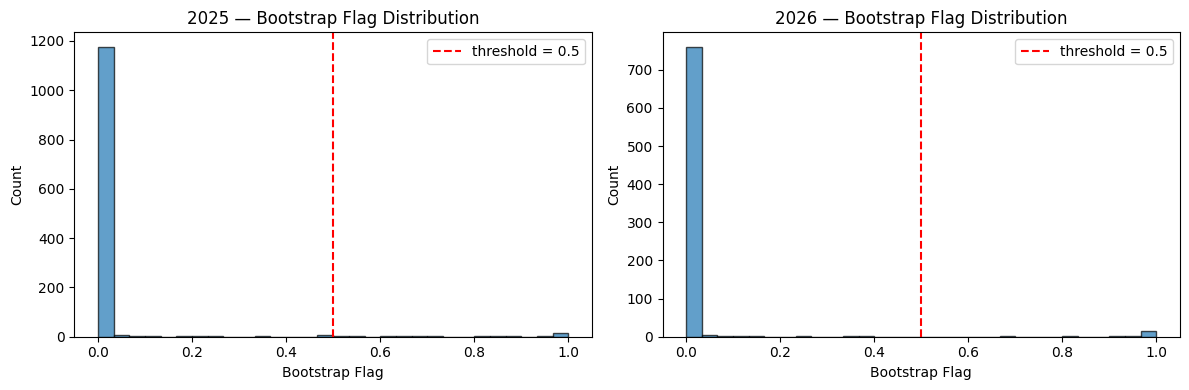

In [42]:
fig, axes = plt.subplots(1, 2, figsize = (12, 4))

for ax, df_yr, yr in [(axes[0], df_iso_25, "2025"), (axes[1], df_iso_26, "2026")]:
    ax.hist(df_yr["bootstrap_flag_pct"], bins = 30, edgecolor = "black", alpha = 0.7)
    ax.axvline(CONSENSUS_THRESHOLD, color = "red", linestyle = "--", label = f"threshold = {CONSENSUS_THRESHOLD}")
    ax.set_xlabel("Bootstrap Flag")
    ax.set_ylabel("Count")
    ax.set_title(f"{yr} — Bootstrap Flag Distribution")
    ax.legend()

plt.tight_layout()
plt.show()

In [43]:
def compute_shap(df, features):
    X = df[features].values
    model = IsolationForest(contamination = "auto", n_estimators = 300, random_state = 42)
    model.fit(X)
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X)

    df_shap = pd.DataFrame(shap_values, columns = features, index = df.index)
    df = df.assign(
        shap_driver = df_shap.apply(lambda row: row.idxmin(), axis = 1),
        shap_driver_value = df_shap.apply(lambda row: row.min(), axis = 1),
    )

    for feat in features:
        median_val = df[feat].median()
        df.loc[df["shap_driver"] == feat, "driver_direction"] = np.where(
            df.loc[df["shap_driver"] == feat, feat] > median_val, "HIGH", "LOW"
        )
    return df, shap_values, explainer


df_iso_25, shap_25, explainer_25 = compute_shap(df_iso_25, iso_kpi_8)
df_iso_26, shap_26, explainer_26 = compute_shap(df_iso_26, iso_kpi_9)

print("SHAP computed for both years.")

SHAP computed for both years.


C:\Users\knguy139\AppData\Local\Temp\ipykernel_31008\2105257128.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_25, df_iso_25[iso_kpi_8].values, feature_names = iso_kpi_8, show = False, plot_type = "bar")
C:\Users\knguy139\AppData\Local\Temp\ipykernel_31008\2105257128.py:8: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_26, df_iso_26[iso_kpi_9].values, feature_names = iso_kpi_9, show = False, plot_type = "bar")


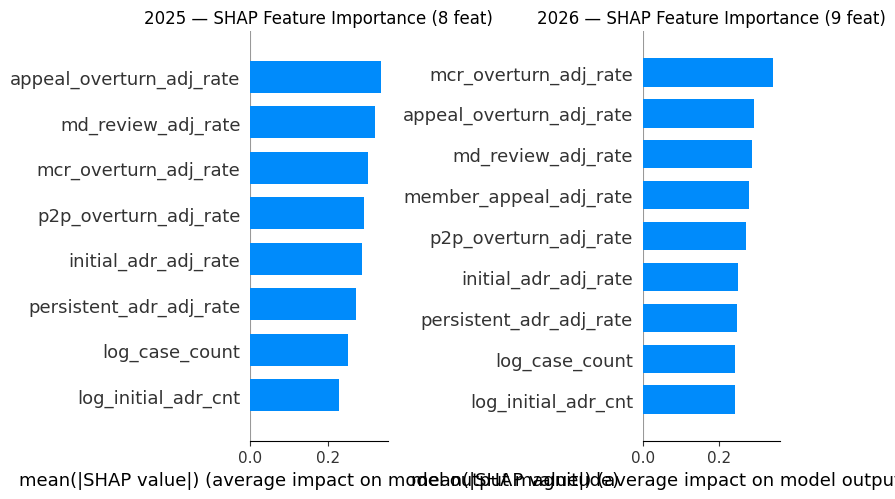

In [45]:
fig, axes = plt.subplots(1, 2, figsize = (14, 5))

plt.sca(axes[0])
shap.summary_plot(shap_25, df_iso_25[iso_kpi_8].values, feature_names = iso_kpi_8, show = False, plot_type = "bar")
axes[0].set_title("2025 — SHAP Feature Importance (8 feat)")

plt.sca(axes[1])
shap.summary_plot(shap_26, df_iso_26[iso_kpi_9].values, feature_names = iso_kpi_9, show = False, plot_type = "bar")
axes[1].set_title("2026 — SHAP Feature Importance (9 feat)")

plt.tight_layout()
plt.show()

In [46]:
flagged_25 = df_iso_25.query("flagged").sort_values("bootstrap_flag_pct", ascending = False)
flagged_26 = df_iso_26.query("flagged").sort_values("bootstrap_flag_pct", ascending = False)

print(f"=== 2025 FLAGGED ({len(flagged_25)}) ===")
print(flagged_25[["hospital_group", "fin_market", "case_count", "bootstrap_flag_pct",
                  "shap_driver", "driver_direction"]].to_string(index = False))

print(f"\n=== 2026 FLAGGED ({len(flagged_26)}) ===")
print(flagged_26[["hospital_group", "fin_market", "case_count", "bootstrap_flag_pct",
                  "shap_driver", "driver_direction"]].to_string(index = False))

cross_year = (
    set(flagged_25[["hospital_group", "fin_market"]].apply(tuple, axis = 1))
    & set(flagged_26[["hospital_group", "fin_market"]].apply(tuple, axis = 1))
)
print(f"\nFlagged BOTH years: {len(cross_year)}")
for h, m in sorted(cross_year):
    print(f"  {h} | {m}")

=== 2025 FLAGGED (30) ===
                          hospital_group fin_market  case_count  bootstrap_flag_pct              shap_driver driver_direction
            TENET HEALTHCARE CORPORATION         TX        4488               1.000    mcr_overturn_adj_rate             HIGH
                                 Steward         FL        2709               1.000  persistent_adr_adj_rate             HIGH
                      COMMUNITY HOSPITAL         OK         128               1.000 appeal_overturn_adj_rate             HIGH
                               Froedtert         WI        8223               1.000    mcr_overturn_adj_rate             HIGH
                            Ascension MI         MI        1330               1.000       md_review_adj_rate              LOW
             JOHNS HOPKINS HEALTH SYSTEM         DC         527               1.000 appeal_overturn_adj_rate             HIGH
                SURGICAL CARE AFFILIATES         IL        1030               1.000 appeal_o

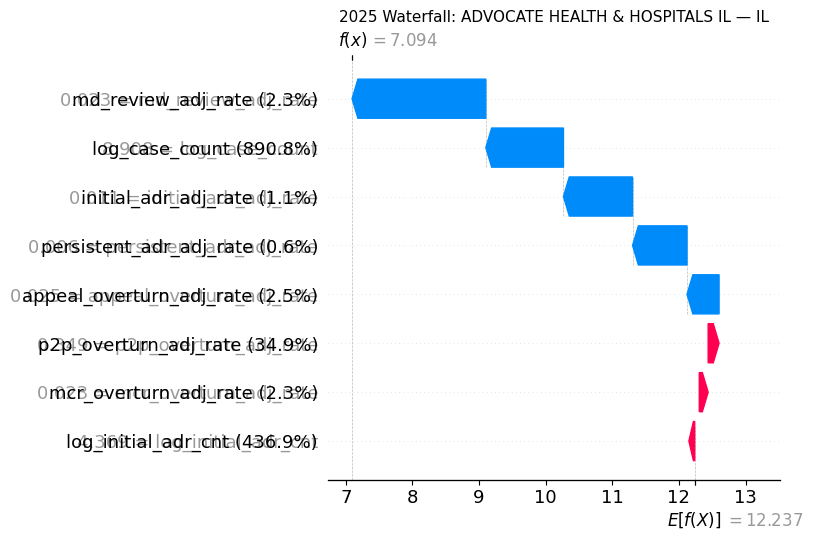

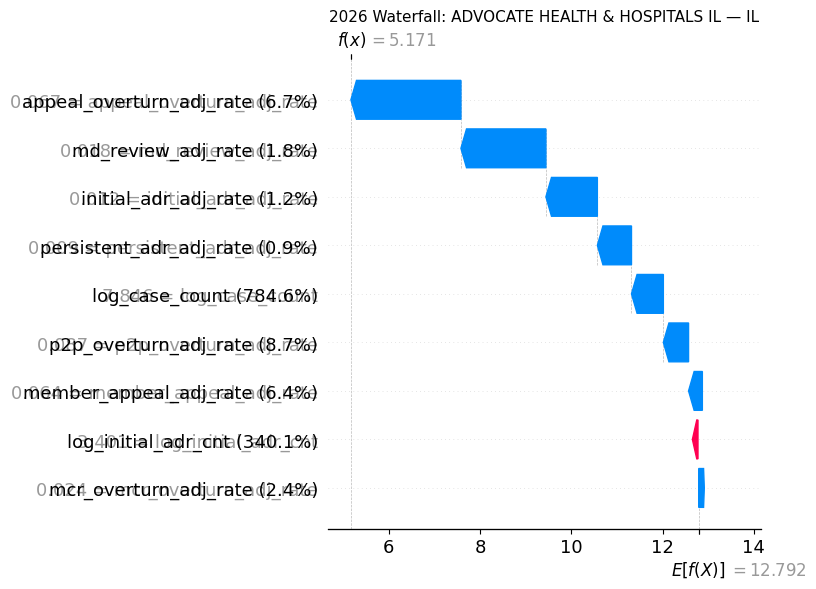

In [48]:
# import matplotlib.colors as mcolors

NAVY = '#1E3477'

TARGET_HOSPITAL = 'ADVOCATE HEALTH & HOSPITALS IL'

def relabel_yaxis(ax, df_row, features):
    for txt in ax.texts:
        txt.set_visible(False)
    labels = ax.get_yticklabels()
    new_labels = []
    for lbl in labels:
        raw = lbl.get_text()
        feat = raw.split(' = ')[0].strip() if ' = ' in raw else raw.strip()
        if feat in features and feat in df_row.index:
            val = df_row[feat]
            pct = f"{val * 100:.1f}%"
            new_labels.append(f"{feat} ({pct})")
        else:
            new_labels.append(raw)
    ax.set_yticklabels(new_labels)

def recolor_bars(fig):
    for ax in fig.get_axes():
        for patch in ax.patches:
            r, g, b = patch.get_facecolor()[:3]
            if b > 0.5 and r < 0.4 and g < 0.5:
                patch.set_facecolor(NAVY)

explanation_25 = explainer_25(df_iso_25[iso_kpi_8].values)
explanation_25.feature_names = iso_kpi_8

mask_25 = df_iso_25['hospital_group'] == TARGET_HOSPITAL
if mask_25.any():
    pos_25 = np.where(mask_25.values)[0][0]
    market_25 = df_iso_25.iloc[pos_25]['fin_market']
    row_25 = df_iso_25.iloc[pos_25]
    shap.plots.waterfall(explanation_25[pos_25], max_display=8, show=False)
    fig = plt.gcf()
    recolor_bars(fig)
    relabel_yaxis(fig.get_axes()[0], row_25, iso_kpi_8)
    plt.title(f"2025 Waterfall: {TARGET_HOSPITAL} — {market_25}", fontsize=11)
    plt.tight_layout()
    plt.show()
else:
    print(f"{TARGET_HOSPITAL} not found in 2025 data")

explanation_26 = explainer_26(df_iso_26[iso_kpi_9].values)
explanation_26.feature_names = iso_kpi_9

mask_26 = df_iso_26['hospital_group'] == TARGET_HOSPITAL
if mask_26.any():
    pos_26 = np.where(mask_26.values)[0][0]
    market_26 = df_iso_26.iloc[pos_26]['fin_market']
    row_26 = df_iso_26.iloc[pos_26]
    shap.plots.waterfall(explanation_26[pos_26], max_display=9, show=False)
    fig = plt.gcf()
    recolor_bars(fig)
    relabel_yaxis(fig.get_axes()[0], row_26, iso_kpi_9)
    plt.title(f"2026 Waterfall: {TARGET_HOSPITAL} — {market_26}", fontsize=11)
    plt.tight_layout()
    plt.show()
else:
    print(f"{TARGET_HOSPITAL} not found in 2026 data")

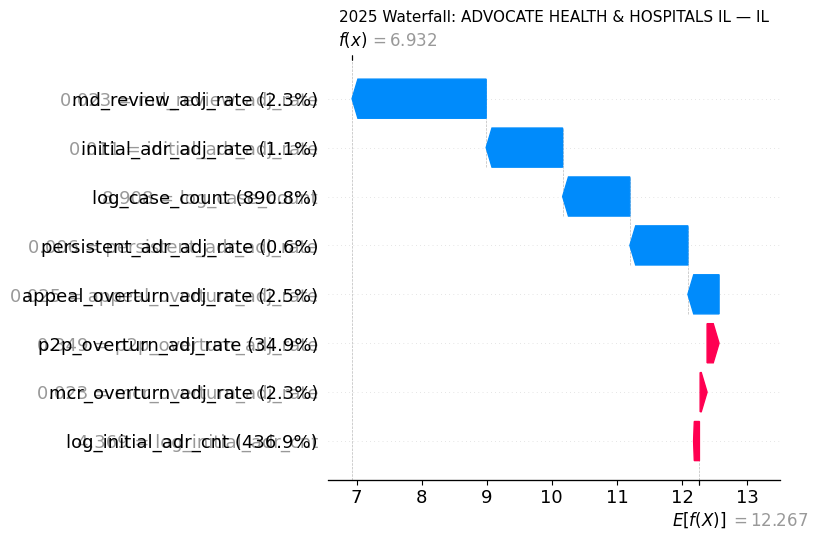

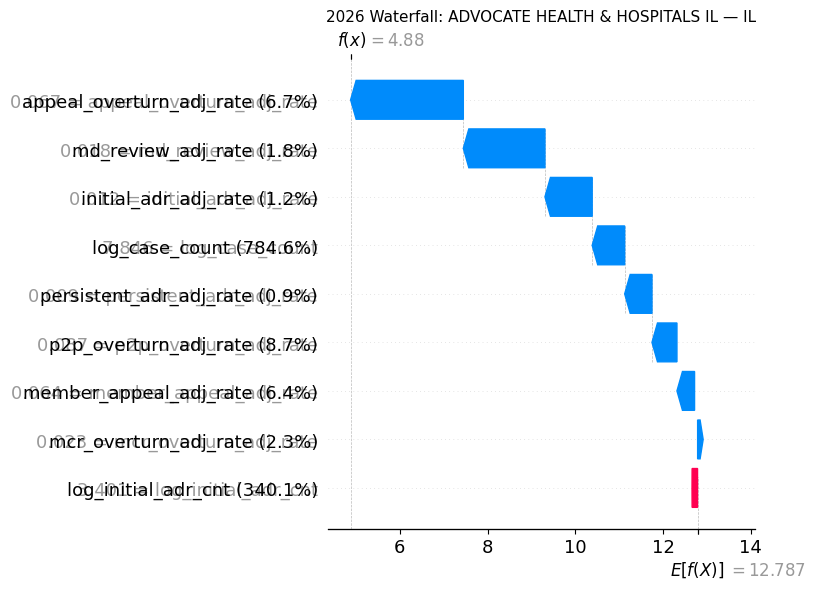

In [15]:
# import matplotlib.colors as mcolors

NAVY = '#1E3477'

TARGET_HOSPITAL = 'ADVOCATE HEALTH & HOSPITALS IL'

def relabel_yaxis(ax, df_row, features):
    for txt in ax.texts:
        txt.set_visible(False)
    labels = ax.get_yticklabels()
    new_labels = []
    for lbl in labels:
        raw = lbl.get_text()
        feat = raw.split(' = ')[0].strip() if ' = ' in raw else raw.strip()
        if feat in features and feat in df_row.index:
            val = df_row[feat]
            pct = f"{val * 100:.1f}%"
            new_labels.append(f"{feat} ({pct})")
        else:
            new_labels.append(raw)
    ax.set_yticklabels(new_labels)

def recolor_bars(fig):
    for ax in fig.get_axes():
        for patch in ax.patches:
            r, g, b = patch.get_facecolor()[:3]
            if b > 0.5 and r < 0.4 and g < 0.5:
                patch.set_facecolor(NAVY)

X_25 = df_iso_25[iso_kpi_8].values
model_25 = IsolationForest(contamination="auto", n_estimators=300, random_state=42)
model_25.fit(X_25)
explainer_25_wf = shap.TreeExplainer(model_25)
explanation_25 = explainer_25_wf(X_25)
explanation_25.feature_names = iso_kpi_8

mask_25 = df_iso_25['hospital_group'] == TARGET_HOSPITAL
if mask_25.any():
    pos_25 = np.where(mask_25.values)[0][0]
    market_25 = df_iso_25.iloc[pos_25]['fin_market']
    row_25 = df_iso_25.iloc[pos_25]
    shap.plots.waterfall(explanation_25[pos_25], max_display=8, show=False)
    fig = plt.gcf()
    recolor_bars(fig)
    relabel_yaxis(fig.get_axes()[0], row_25, iso_kpi_8)
    plt.title(f"2025 Waterfall: {TARGET_HOSPITAL} — {market_25}", fontsize=11)
    plt.tight_layout()
    plt.show()
else:
    print(f"{TARGET_HOSPITAL} not found in 2025 data")

X_26 = df_iso_26[iso_kpi_9].values
model_26 = IsolationForest(contamination="auto", n_estimators=300, random_state=42)
model_26.fit(X_26)
explainer_26_wf = shap.TreeExplainer(model_26)
explanation_26 = explainer_26_wf(X_26)
explanation_26.feature_names = iso_kpi_9

mask_26 = df_iso_26['hospital_group'] == TARGET_HOSPITAL
if mask_26.any():
    pos_26 = np.where(mask_26.values)[0][0]
    market_26 = df_iso_26.iloc[pos_26]['fin_market']
    row_26 = df_iso_26.iloc[pos_26]
    shap.plots.waterfall(explanation_26[pos_26], max_display=9, show=False)
    fig = plt.gcf()
    recolor_bars(fig)
    relabel_yaxis(fig.get_axes()[0], row_26, iso_kpi_9)
    plt.title(f"2026 Waterfall: {TARGET_HOSPITAL} — {market_26}", fontsize=11)
    plt.tight_layout()
    plt.show()
else:
    print(f"{TARGET_HOSPITAL} not found in 2026 data")

In [49]:
print("=" * 70)
print("LOC IF v7 — SUMMARY")
print("=" * 70)
print(f"""
Architecture: Separate per-year Isolation Forest (Option 3)
  2025: 8 features (excludes member_appeal) | {len(df_iso_25)} hospital-markets
  2026: 9 features (includes member_appeal) | {len(df_iso_26)} hospital-markets

Bootstrap: {N_BOOT}x resamples, consensus threshold = {CONSENSUS_THRESHOLD}
  2025 flagged: {df_iso_25['flagged'].sum()}
  2026 flagged: {df_iso_26['flagged'].sum()}
  Both years:  {len(cross_year)}

SHAP: TreeExplainer per-year model, driver = feature with most negative SHAP

Key changes from v4:
  - Separate models per year (no member_appeal imputation)
  - k_map estimated from full >=30-case population
  - Consensus threshold lowered to 0.60 (stability-calibrated)
""")

LOC IF v7 — SUMMARY

Architecture: Separate per-year Isolation Forest (Option 3)
  2025: 8 features (excludes member_appeal) | 1226 hospital-markets
  2026: 9 features (includes member_appeal) | 790 hospital-markets

Bootstrap: 200x resamples, consensus threshold = 0.5
  2025 flagged: 30
  2026 flagged: 19
  Both years:  4

SHAP: TreeExplainer per-year model, driver = feature with most negative SHAP

Key changes from v4:
  - Separate models per year (no member_appeal imputation)
  - k_map estimated from full >=30-case population
  - Consensus threshold lowered to 0.60 (stability-calibrated)



In [17]:
# find optimal consensus threshold via Hartigan's dip test on bootstrap distribution
# if bimodal: threshold = valley between peaks
# if unimodal: use majority-vote (0.50) as floor, report sensitivity

from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d

def find_optimal_threshold(boot_pcts, year_label):
    hist_vals, bin_edges = np.histogram(boot_pcts, bins = 50, range = (0, 1))
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    # smooth to find stable peaks/valleys
    smoothed = gaussian_filter1d(hist_vals.astype(float), sigma = 2)

    # find peaks (modes) in the distribution
    peaks, peak_props = find_peaks(smoothed, height = max(smoothed) * 0.1)

    # find valleys (inverted peaks)
    valleys, _ = find_peaks(-smoothed)

    # only consider valleys between 0.3 and 0.9 (sensible range)
    valid_valleys = [v for v in valleys if 0.3 <= bin_centers[v] <= 0.9]

    if len(peaks) >= 2 and len(valid_valleys) >= 1:
        # bimodal — use the deepest valley between the two highest peaks
        top2_peaks = sorted(peaks, key = lambda p: smoothed[p], reverse = True)[:2]
        lo, hi = sorted(top2_peaks)
        between_valleys = [v for v in valid_valleys if lo < v < hi]
        if between_valleys:
            best_valley = min(between_valleys, key = lambda v: smoothed[v])
            threshold = bin_centers[best_valley]
            method = "bimodal valley"
        else:
            threshold = bin_centers[valid_valleys[np.argmin(smoothed[valid_valleys])]]
            method = "deepest valley (no between-peak valley)"
    else:
        # unimodal — use 0.50 majority vote
        threshold = 0.50
        method = "unimodal (majority vote default)"

    print(f"\n{year_label}:")
    print(f"  Detected peaks: {len(peaks)} at positions {[f'{bin_centers[p]:.2f}' for p in peaks]}")
    print(f"  Method: {method}")
    print(f"  Optimal threshold: {threshold:.3f}")

    return threshold, smoothed, bin_centers, peaks, valid_valleys


thresh_25, sm_25, bc_25, pk_25, vl_25 = find_optimal_threshold(df_iso_25["bootstrap_flag_pct"].values, "2025")
thresh_26, sm_26, bc_26, pk_26, vl_26 = find_optimal_threshold(df_iso_26["bootstrap_flag_pct"].values, "2026")

# sensitivity table: how many flagged at each candidate threshold
print("\n" + "=" * 60)
print("Sensitivity Table — flagged count by threshold")
print("=" * 60)
print(f"{'Threshold':<12} {'2025 flagged':<15} {'2026 flagged':<15}")
print("-" * 42)
for t in [0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80]:
    n25 = (df_iso_25["bootstrap_flag_pct"] >= t).sum()
    n26 = (df_iso_26["bootstrap_flag_pct"] >= t).sum()
    marker = " <-- data-driven" if abs(t - thresh_25) < 0.03 or abs(t - thresh_26) < 0.03 else ""
    print(f"{t:<12.2f} {n25:<15} {n26:<15}{marker}")

print(f"\nRecommended threshold: {max(thresh_25, thresh_26):.2f} (use the more conservative year)")


2025:
  Detected peaks: 0 at positions []
  Method: unimodal (majority vote default)
  Optimal threshold: 0.500

2026:
  Detected peaks: 0 at positions []
  Method: unimodal (majority vote default)
  Optimal threshold: 0.500

Sensitivity Table — flagged count by threshold
Threshold    2025 flagged    2026 flagged   
------------------------------------------
0.50         33              19              <-- data-driven
0.55         28              19             
0.60         27              19             
0.65         25              19             
0.70         24              19             
0.75         21              19             
0.80         21              18             

Recommended threshold: 0.50 (use the more conservative year)


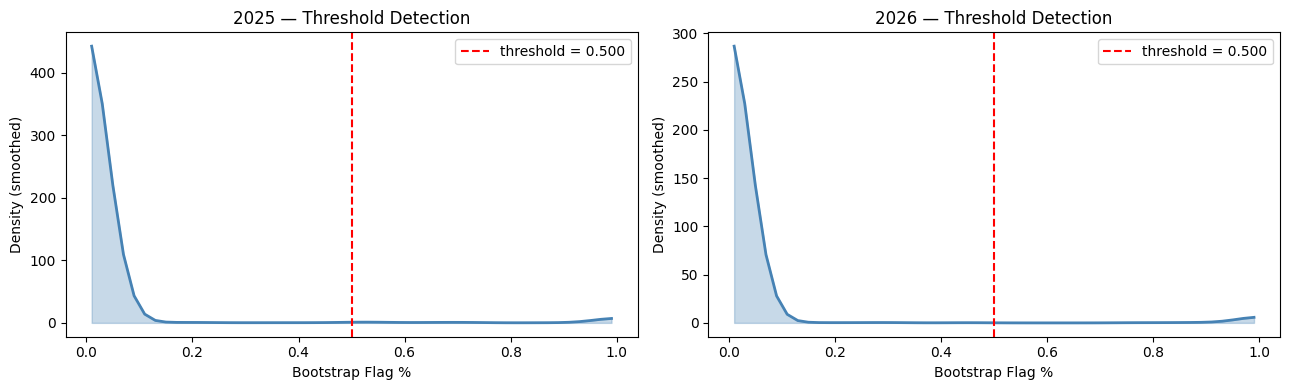

In [18]:
fig, axes = plt.subplots(1, 2, figsize = (13, 4))

for ax, sm, bc, pks, vls, thresh, yr in [
    (axes[0], sm_25, bc_25, pk_25, vl_25, thresh_25, "2025"),
    (axes[1], sm_26, bc_26, pk_26, vl_26, thresh_26, "2026"),
]:
    ax.plot(bc, sm, color = "steelblue", linewidth = 2)
    ax.fill_between(bc, sm, alpha = 0.3, color = "steelblue")
    ax.axvline(thresh, color = "red", linestyle = "--", linewidth = 1.5, label = f"threshold = {thresh:.3f}")
    for p in pks:
        ax.axvline(bc[p], color = "green", linestyle = ":", alpha = 0.6)
    ax.set_xlabel("Bootstrap Flag %")
    ax.set_ylabel("Density (smoothed)")
    ax.set_title(f"{yr} — Threshold Detection")
    ax.legend()

plt.tight_layout()
plt.show()

In [19]:
df_25_broad = df_2025.query("case_count >= 30")
df_26_broad = df_2026.query("case_count >= 30")

rate_configs_6 = {
    "initial_adr":     ("initial_adr_cnt",    "case_count"),
    "persistent_adr":  ("persistent_adr_cnt", "case_count"),
    "p2p_overturn":    ("p2p_ovrtn_cnt",      "initial_adr_cnt"),
    "appeal_overturn": ("appeal_ovrtn_cnt",   "initial_adr_cnt"),
    "mcr_overturn":    ("mcr_ovrtn_cnt",      "initial_adr_cnt"),
    "md_review":       ("md_reviewed_cnt",    "case_count"),
}

rows = []
for feat, (num, denom) in rate_configs_6.items():
    k_25 = mom_optimal_k(df_25_broad[num], df_25_broad[denom])
    k_26 = mom_optimal_k(df_26_broad[num], df_26_broad[denom])
    k_pooled = k_map[feat]
    pct_diff = abs(k_25 - k_26) / k_pooled * 100
    rows.append({
        "feature": feat,
        "k_2025": round(k_25, 1),
        "k_2026": round(k_26, 1),
        "k_pooled": round(k_pooled, 1),
        "abs_diff_25_26": round(abs(k_25 - k_26), 1),
        "pct_diff_vs_pooled": round(pct_diff, 1),
    })

# member_appeal only has 2026 data — no per-year comparison possible
rows.append({
    "feature": "member_appeal",
    "k_2025": np.nan,
    "k_2026": round(k_map["member_appeal"], 1),
    "k_pooled": round(k_map["member_appeal"], 1),
    "abs_diff_25_26": np.nan,
    "pct_diff_vs_pooled": np.nan,
})

df_k_compare = pd.DataFrame(rows)
print(df_k_compare.to_string(index = False))

print("\n" + "-" * 60)
max_diff = df_k_compare["pct_diff_vs_pooled"].max()
print(f"Max per-year divergence: {max_diff:.1f}% of pooled k")
if max_diff < 30:
    print("PASS — per-year k estimates are within 30% of pooled. Pooling assumption holds.")
else:
    concern_feats = df_k_compare.query("pct_diff_vs_pooled >= 30")["feature"].tolist()
    print(f"CONCERN — divergence >=30% on: {concern_feats}")
    print("Consider per-year k for these features, or investigate year-over-year rate shifts.")

        feature  k_2025  k_2026  k_pooled  abs_diff_25_26  pct_diff_vs_pooled
    initial_adr     8.3     8.5       8.3             0.2                 2.2
 persistent_adr    15.0    15.3      15.1             0.4                 2.3
   p2p_overturn     8.3     9.5       8.8             1.2                13.5
appeal_overturn     1.3     0.7       1.1             0.6                57.5
   mcr_overturn   150.4    50.0     204.8           100.4                49.0
      md_review     2.1     1.9       2.0             0.1                 7.2
  member_appeal     NaN     5.0       5.0             NaN                 NaN

------------------------------------------------------------
Max per-year divergence: 57.5% of pooled k
CONCERN — divergence >=30% on: ['appeal_overturn', 'mcr_overturn']
Consider per-year k for these features, or investigate year-over-year rate shifts.


In [20]:

df_25_broad = df_2025.query("case_count >= 30")
df_26_broad = df_2026.query("case_count >= 30")

rate_configs_6 = {
    "initial_adr":     ("initial_adr_cnt",    "case_count"),
    "persistent_adr":  ("persistent_adr_cnt", "case_count"),
    "p2p_overturn":    ("p2p_ovrtn_cnt",      "initial_adr_cnt"),
    "appeal_overturn": ("appeal_ovrtn_cnt",   "initial_adr_cnt"),
    "mcr_overturn":    ("mcr_ovrtn_cnt",      "initial_adr_cnt"),
    "md_review":       ("md_reviewed_cnt",    "case_count"),
}

rows = []
for feat, (num, denom) in rate_configs_6.items():
    k_25 = mom_optimal_k(df_25_broad[num], df_25_broad[denom])
    k_26 = mom_optimal_k(df_26_broad[num], df_26_broad[denom])
    k_pooled = k_map[feat]
    pct_diff = abs(k_25 - k_26) / k_pooled * 100
    rows.append({
        "feature": feat,
        "k_2025": round(k_25, 1),
        "k_2026": round(k_26, 1),
        "k_pooled": round(k_pooled, 1),
        "abs_diff_25_26": round(abs(k_25 - k_26), 1),
        "pct_diff_vs_pooled": round(pct_diff, 1),
    })

# member_appeal only has 2026 data — no per-year comparison possible
rows.append({
    "feature": "member_appeal",
    "k_2025": np.nan,
    "k_2026": round(k_map["member_appeal"], 1),
    "k_pooled": round(k_map["member_appeal"], 1),
    "abs_diff_25_26": np.nan,
    "pct_diff_vs_pooled": np.nan,
})

df_k_compare = pd.DataFrame(rows)
print(df_k_compare.to_string(index = False))

print("\n" + "-" * 60)
max_diff = df_k_compare["pct_diff_vs_pooled"].max()
print(f"Max per-year divergence: {max_diff:.1f}% of pooled k")
if max_diff < 30:
    print("PASS — per-year k estimates are within 30% of pooled. Pooling assumption holds.")
else:
    concern_feats = df_k_compare.query("pct_diff_vs_pooled >= 30")["feature"].tolist()
    print(f"CONCERN — divergence >=30% on: {concern_feats}")
    print("Consider per-year k for these features, or investigate year-over-year rate shifts.")

        feature  k_2025  k_2026  k_pooled  abs_diff_25_26  pct_diff_vs_pooled
    initial_adr     8.3     8.5       8.3             0.2                 2.2
 persistent_adr    15.0    15.3      15.1             0.4                 2.3
   p2p_overturn     8.3     9.5       8.8             1.2                13.5
appeal_overturn     1.3     0.7       1.1             0.6                57.5
   mcr_overturn   150.4    50.0     204.8           100.4                49.0
      md_review     2.1     1.9       2.0             0.1                 7.2
  member_appeal     NaN     5.0       5.0             NaN                 NaN

------------------------------------------------------------
Max per-year divergence: 57.5% of pooled k
CONCERN — divergence >=30% on: ['appeal_overturn', 'mcr_overturn']
Consider per-year k for these features, or investigate year-over-year rate shifts.


In [21]:
DRIVER_RENAME = {
    'md_review_adj_rate': 'md_escalation_rate',
    'member_appeal_adj_rate': 'member_appeal_rate',
    'persistent_adr_adj_rate': 'persistent_adr_rate',
    'initial_adr_adj_rate': 'initial_adr_rate',
}
KEEP_DRIVERS = set(DRIVER_RENAME.keys())

def build_output_table(df, year_label, features):
    df = df.copy()
    median_vals = df[features].median()
    df['driver_median'] = df['shap_driver'].map(lambda d: median_vals.get(d, np.nan))
    df['driver_actual'] = df.apply(lambda row: row.get(row['shap_driver'], np.nan), axis=1)

    out = df.query('flagged').copy()
    out = out[out['shap_driver'].isin(KEEP_DRIVERS)]
    out = out.sort_values('case_count', ascending=False)

    out['shap_driver'] = out['shap_driver'].map(DRIVER_RENAME)
    out['driver_actual_fmt'] = (out['driver_actual'] * 100).round(1).astype(str) + '%'
    out['driver_median_fmt'] = (out['driver_median'] * 100).round(1).astype(str) + '%'
    out['bootstrap_flag_pct'] = (out['bootstrap_flag_pct'] * 100).round(1)

    out = out[[
        'hospital_group', 'fin_market', 'case_count',
        'bootstrap_flag_pct', 'shap_driver',
        'driver_direction', 'driver_actual_fmt', 'driver_median_fmt'
    ]].copy()
    out.columns = ['Hospital Group', 'Market', 'Cases',
                   'Bootstrap %', 'SHAP Driver',
                   'Direction', 'Driver Value', 'Median']
    print(f"\n{'='*80}")
    print(f" {year_label} — FLAGGED HOSPITALS (sorted by case count desc)")
    print(f"{'='*80}")
    print(out.to_string(index=False))
    return out

table_25 = build_output_table(df_iso_25, '2025', iso_kpi_8)
table_26 = build_output_table(df_iso_26, '2026', iso_kpi_9)



 2025 — FLAGGED HOSPITALS (sorted by case count desc)
                          Hospital Group Market  Cases  Bootstrap %         SHAP Driver Direction Driver Value Median
          ADVOCATE HEALTH & HOSPITALS IL     IL   7393        100.0  md_escalation_rate       LOW         2.3%  70.1%
                                 Steward     FL   2709        100.0 persistent_adr_rate      HIGH        38.9%  14.9%
                             MAYO CLINIC     MN   1695        100.0  md_escalation_rate       LOW         5.8%  70.1%
                            Ascension MI     MI   1330        100.0  md_escalation_rate       LOW        11.6%  70.1%
                   Albany Medical Center     NY    935         50.5  md_escalation_rate       LOW        23.7%  70.1%
HEALTH CARE AUTHORITY OF THE CITY OF ANN     AL    860        100.0  md_escalation_rate       LOW         6.4%  70.1%
        ADVOCATE NORTHSIDE HEALTH SYSTEM     IL    721         98.5  md_escalation_rate       LOW         3.1%  70.1%
 

In [22]:
table_25

,Hospital Group,Market,Cases,Bootstrap %,SHAP Driver,Direction,Driver Value,Median
14,ADVOCATE HEALTH & HOSPITALS IL,IL,7393,100.0,md_escalation_rate,LOW,2.3%,70.1%
1046,Steward,FL,2709,100.0,persistent_adr_rate,HIGH,38.9%,14.9%
97,MAYO CLINIC,MN,1695,100.0,md_escalation_rate,LOW,5.8%,70.1%
1628,Ascension MI,MI,1330,100.0,md_escalation_rate,LOW,11.6%,70.1%
247,Albany Medical Center,NY,935,50.5,md_escalation_rate,LOW,23.7%,70.1%
1480,HEALTH CARE AUTHORITY OF THE CITY OF ANN,AL,860,100.0,md_escalation_rate,LOW,6.4%,70.1%
1328,ADVOCATE NORTHSIDE HEALTH SYSTEM,IL,721,98.5,md_escalation_rate,LOW,3.1%,70.1%
959,Mosaic Life Care,MO,465,72.0,md_escalation_rate,LOW,8.6%,70.1%
41,VIRTUA WILLINGBORO HOSPITAL,PA,292,53.5,persistent_adr_rate,HIGH,44.0%,14.9%
342,PIH Hospital,CA-S,290,96.0,persistent_adr_rate,HIGH,34.8%,14.9%


In [50]:
DRIVER_RENAME = {
    'md_review_adj_rate': 'md_escalation_rate',
    'member_appeal_adj_rate': 'member_appeal_rate',
    'persistent_adr_adj_rate': 'persistent_adr_rate',
    'initial_adr_adj_rate': 'initial_adr_rate',
}
KEEP_DRIVERS = set(DRIVER_RENAME.keys())

def build_output_table(df, year_label, features):
    df = df.copy()
    median_vals = df[features].median()
    df['driver_median'] = df['shap_driver'].map(lambda d: median_vals.get(d, np.nan))
    df['driver_actual'] = df.apply(lambda row: row.get(row['shap_driver'], np.nan), axis=1)

    out = df.query('flagged').copy()
    out = out[out['shap_driver'].isin(KEEP_DRIVERS)]
    out = out.sort_values('case_count', ascending=False)

    out['shap_driver'] = out['shap_driver'].map(DRIVER_RENAME)
    out['driver_actual_fmt'] = (out['driver_actual'] * 100).round(1).astype(str) + '%'
    out['driver_median_fmt'] = (out['driver_median'] * 100).round(1).astype(str) + '%'
    out['bootstrap_flag_pct'] = (out['bootstrap_flag_pct'] * 100).round(1)

    out = out[[
        'hospital_group', 'fin_market', 'case_count',
        'bootstrap_flag_pct', 'shap_driver',
        'driver_direction', 'driver_actual_fmt', 'driver_median_fmt'
    ]].copy()
    out.columns = ['Hospital Group', 'Market', 'Cases',
                   'Bootstrap %', 'SHAP Driver',
                   'Direction', 'Driver Value', 'Median']
    print(f"\n{year_label} — FLAGGED HOSPITALS (sorted by case count desc)")
    print(out.to_csv(sep='\t', index=False))
    return out

table_25 = build_output_table(df_iso_25, '2025', iso_kpi_8)
table_26 = build_output_table(df_iso_26, '2026', iso_kpi_9)


2025 — FLAGGED HOSPITALS (sorted by case count desc)
Hospital Group	Market	Cases	Bootstrap %	SHAP Driver	Direction	Driver Value	Median
ADVOCATE HEALTH & HOSPITALS IL	IL	7393	100.0	md_escalation_rate	LOW	2.3%	70.1%
Steward	FL	2709	100.0	persistent_adr_rate	HIGH	38.9%	14.9%
MAYO CLINIC	MN	1695	100.0	md_escalation_rate	LOW	5.8%	70.1%
Ascension MI	MI	1330	100.0	md_escalation_rate	LOW	11.6%	70.1%
HEALTH CARE AUTHORITY OF THE CITY OF ANN	AL	860	100.0	md_escalation_rate	LOW	6.4%	70.1%
ADVOCATE NORTHSIDE HEALTH SYSTEM	IL	721	100.0	md_escalation_rate	LOW	3.1%	70.1%
Mosaic Life Care	MO	465	72.5	md_escalation_rate	LOW	8.6%	70.1%
PIH Hospital	CA-S	290	95.0	persistent_adr_rate	HIGH	34.4%	14.9%
LARKIN COMMUNITY HOSPITAL	FL	182	61.5	persistent_adr_rate	HIGH	39.6%	14.9%
WESTCHESTER GENERAL HOSPITAL	FL	114	100.0	persistent_adr_rate	HIGH	43.4%	14.9%
NJMHMC	NJ	51	86.0	initial_adr_rate	HIGH	66.0%	28.9%


2026 — FLAGGED HOSPITALS (sorted by case count desc)
Hospital Group	Market	Cases	Bootstrap %	SHAP Dri

In [24]:
DRIVER_RENAME = {
    'md_review_adj_rate': 'md_escalation_rate',
    'member_appeal_adj_rate': 'member_appeal_rate',
    'persistent_adr_adj_rate': 'persistent_adr_rate',
    'initial_adr_adj_rate': 'initial_adr_rate',
}
KEEP_DRIVERS = set(DRIVER_RENAME.keys())

def build_output_table(df, year_label, features):
    df = df.copy()
    median_vals = df[features].median()
    df['driver_median'] = df['shap_driver'].map(lambda d: median_vals.get(d, np.nan))
    df['driver_actual'] = df.apply(lambda row: row.get(row['shap_driver'], np.nan), axis=1)

    out = df.query('flagged').copy()
    out = out[out['shap_driver'].isin(KEEP_DRIVERS)]
    out = out.sort_values('case_count', ascending=False)

    out['shap_driver'] = out['shap_driver'].map(DRIVER_RENAME)
    out['driver_actual_fmt'] = (out['driver_actual'] * 100).round(1).astype(str) + '%'
    out['driver_median_fmt'] = (out['driver_median'] * 100).round(1).astype(str) + '%'
    out['bootstrap_flag_pct'] = (out['bootstrap_flag_pct'] * 100).round(1)

    out = out[[
        'hospital_group', 'fin_market', 'case_count',
        'bootstrap_flag_pct', 'shap_driver',
        'driver_direction', 'driver_actual_fmt', 'driver_median_fmt'
    ]].copy()
    out.insert(0, 'year', year_label)
    out.columns = ['Year', 'Hospital Group', 'Market', 'Cases',
                   'Bootstrap %', 'SHAP Driver',
                   'Direction', 'Driver Value', 'Median']
    return out

table_25 = build_output_table(df_iso_25, '2025', iso_kpi_8)
table_26 = build_output_table(df_iso_26, '2026', iso_kpi_9)

combined = pd.concat([table_25, table_26], ignore_index=True)
combined.to_csv(r'C:\Users\knguy139\Documents\Projects\Data\LOC_IF_Output.csv', index=False)
# print(f"Exported {len(combined)} rows to C:\Users\knguy139\Documents\Projects\Data\LOC_IF_Output.csv' ")

PermissionError: [Errno 13] Permission denied: 'C:\\Users\\knguy139\\Documents\\Projects\\Data\\LOC_IF_Output.csv'

In [ ]:
print(f"Median member_appeal_adj_rate (2026): {df_iso_26['member_appeal_adj_rate'].median():.4f} ({df_iso_26['member_appeal_adj_rate'].median()*100:.2f}%)")

NameError: name 'df_iso_26' is not defined

In [51]:
print(df_iso_26['member_appeal_adj_rate'].describe())
print(f"\nPercentiles:")
for p in [5, 10, 25, 50, 75, 90, 95]:
    val = df_iso_26['member_appeal_adj_rate'].quantile(p/100)
    print(f"  P{p}: {val*100:.2f}%")

count    790.000000
mean       0.027079
std        0.068446
min        0.000383
25%        0.005152
50%        0.009935
75%        0.022349
max        0.669396
Name: member_appeal_adj_rate, dtype: float64

Percentiles:
  P5: 0.18%
  P10: 0.26%
  P25: 0.52%
  P50: 0.99%
  P75: 2.23%
  P90: 5.30%
  P95: 8.42%


In [53]:
DRIVER_RENAME = {
    'md_review_adj_rate': 'md_escalation_rate',
    'member_appeal_adj_rate': 'member_appeal_rate',
    'persistent_adr_adj_rate': 'persistent_adr_rate',
    'initial_adr_adj_rate': 'initial_adr_rate',
    'p2p_overturn_adj_rate' : 'p2p_overturn_rate'
}
KEEP_DRIVERS = set(DRIVER_RENAME.keys())

def build_output_table(df, year_label, features, explainer, shap_vals):
    df = df.copy()
    X = df[features].values
    model = IsolationForest(contamination='auto', n_estimators=300, random_state=42)
    model.fit(X)
    df['anomaly_score'] = model.decision_function(X)

    median_vals = df[features].median()
    df['driver_median'] = df['shap_driver'].map(lambda d: median_vals.get(d, np.nan))
    df['driver_actual'] = df.apply(lambda row: row.get(row['shap_driver'], np.nan), axis=1)

    out = df.query('flagged').copy()
    out = out[out['shap_driver'].isin(KEEP_DRIVERS)]
    out = out.sort_values('case_count', ascending=False)

    out['driver_display'] = out['shap_driver'].map(DRIVER_RENAME) + ' (' + out['driver_direction'] + ')'
    out['driver_value_fmt'] = (out['driver_actual'] * 100).round(1).astype(str) + '%'
    out['median_fmt'] = (out['driver_median'] * 100).round(1).astype(str) + '%'
    out['reldiff'] = ((out['driver_actual'] - out['driver_median']) / out['driver_median'] * 100).round(1).astype(str) + '%'
    out['anomaly_score'] = out['anomaly_score'].round(4)
    out['bootstrap_flag_pct'] = (out['bootstrap_flag_pct'] * 100).round(1)

    out = out[[
        'hospital_group', 'fin_market', 'case_count', 'anomaly_score',
        'bootstrap_flag_pct', 'driver_display',
        'driver_value_fmt', 'median_fmt', 'reldiff'
    ]].copy()
    out.insert(0, 'year', year_label)
    out.columns = ['Year', 'Hospital Group', 'Market', 'Case Count', 'Anomaly Score',
                   'Bootstrap %', 'Top Anomaly Driver',
                   'Driver Value', 'Median', 'RelDiff']
    return out

table_25 = build_output_table(df_iso_25, '2025', iso_kpi_8, explainer_25, shap_25)
table_26 = build_output_table(df_iso_26, '2026', iso_kpi_9, explainer_26, shap_26)

combined = pd.concat([table_25, table_26], ignore_index=True)
# combined.to_csv(r'C:\Users\knguy139\Documents\Projects\Data\Output\loc_if_flagged_output.csv', index=False)
# print(f"Exported {len(combined)} rows to LOC/loc_if_flagged_output.csv")
# print(combined.to_string(index=False))

combined

,Year,Hospital Group,Market,Case Count,Anomaly Score,Bootstrap %,Top Anomaly Driver,Driver Value,Median,RelDiff
0,2025,ADVOCATE HEALTH & HOSPITALS IL,IL,7393,-0.1188,100.0,md_escalation_rate (LOW),2.3%,70.1%,-96.7%
1,2025,Steward,FL,2709,-0.1165,100.0,persistent_adr_rate (HIGH),38.9%,14.9%,161.6%
2,2025,MAYO CLINIC,MN,1695,-0.1133,100.0,md_escalation_rate (LOW),5.8%,70.1%,-91.7%
3,2025,Ascension MI,MI,1330,-0.1181,100.0,md_escalation_rate (LOW),11.6%,70.1%,-83.4%
4,2025,HEALTH CARE AUTHORITY OF THE CITY OF ANN,AL,860,-0.0944,100.0,md_escalation_rate (LOW),6.4%,70.1%,-90.9%
5,2025,ADVOCATE NORTHSIDE HEALTH SYSTEM,IL,721,-0.0723,100.0,md_escalation_rate (LOW),3.1%,70.1%,-95.6%
6,2025,Mosaic Life Care,MO,465,-0.0549,72.5,md_escalation_rate (LOW),8.6%,70.1%,-87.7%
7,2025,PIH Hospital,CA-S,290,-0.0643,95.0,persistent_adr_rate (HIGH),34.4%,14.9%,131.7%
8,2025,LARKIN COMMUNITY HOSPITAL,FL,182,-0.0671,61.5,persistent_adr_rate (HIGH),39.6%,14.9%,166.4%
9,2025,WESTCHESTER GENERAL HOSPITAL,FL,114,-0.1176,100.0,persistent_adr_rate (HIGH),43.4%,14.9%,192.1%


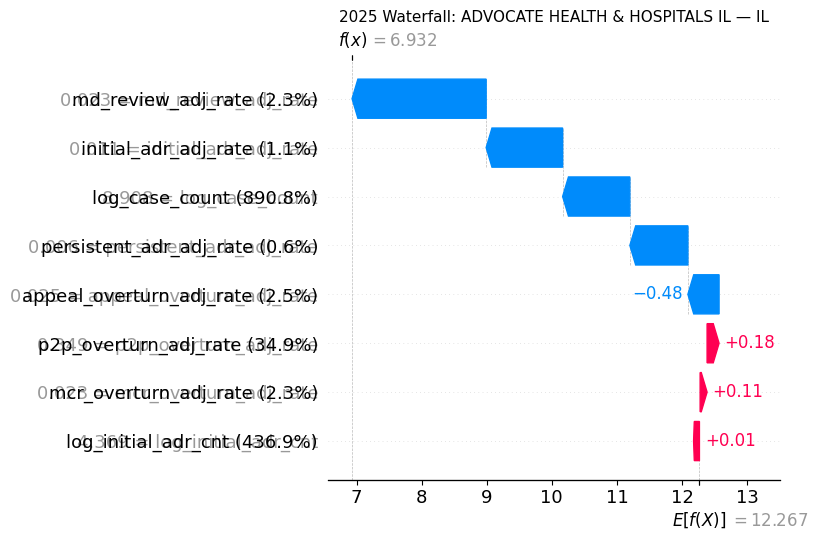

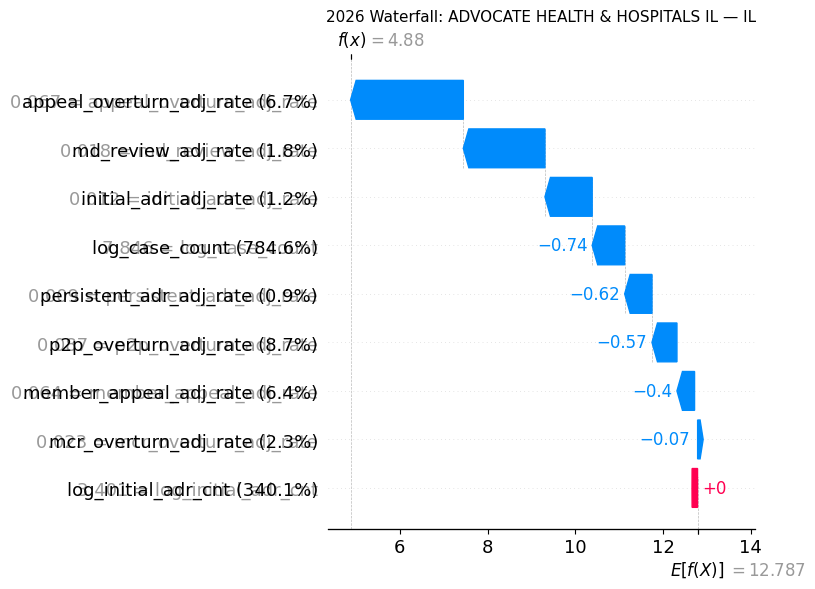

In [ ]:
import matplotlib.colors as mcolors

NAVY = '#1E3477'

TARGET_HOSPITAL = 'ADVOCATE HEALTH & HOSPITALS IL'

def _is_gray_text(txt):
    c = txt.get_color()
    if isinstance(c, str):
        if c in ('grey', 'gray', '#999999', '#888888', '#aaaaaa'):
            return True
        try:
            rgb = mcolors.to_rgb(c)
        except ValueError:
            return False
        return abs(rgb[0] - rgb[1]) < 0.05 and abs(rgb[1] - rgb[2]) < 0.05 and rgb[0] > 0.4
    if hasattr(c, '__len__') and len(c) >= 3:
        r, g, b = float(c[0]), float(c[1]), float(c[2])
        return abs(r - g) < 0.05 and abs(g - b) < 0.05 and r > 0.4
    return False

def relabel_yaxis(ax, df_row, features):
    for txt in list(ax.texts):
        if _is_gray_text(txt):
            txt.remove()
    for sibling_ax in ax.get_figure().get_axes():
        if sibling_ax is not ax:
            for txt in list(sibling_ax.texts):
                if _is_gray_text(txt):
                    txt.remove()
    labels = ax.get_yticklabels()
    new_labels = []
    for lbl in labels:
        raw = lbl.get_text()
        feat = raw.split(' = ')[0].strip() if ' = ' in raw else raw.strip()
        if feat in features and feat in df_row.index:
            val = df_row[feat]
            pct = f"{val * 100:.1f}%"
            new_labels.append(f"{feat} ({pct})")
        else:
            new_labels.append(raw)
    ax.set_yticklabels(new_labels)

def recolor_bars(fig):
    for ax in fig.get_axes():
        for patch in ax.patches:
            r, g, b = patch.get_facecolor()[:3]
            if b > 0.5 and r < 0.4 and g < 0.5:
                patch.set_facecolor(NAVY)

explanation_25 = explainer_25(df_iso_25[iso_kpi_8].values)
explanation_25.feature_names = iso_kpi_8

mask_25 = df_iso_25['hospital_group'] == TARGET_HOSPITAL
if mask_25.any():
    pos_25 = np.where(mask_25.values)[0][0]
    market_25 = df_iso_25.iloc[pos_25]['fin_market']
    row_25 = df_iso_25.iloc[pos_25]
    shap.plots.waterfall(explanation_25[pos_25], max_display=8, show=False)
    fig = plt.gcf()
    recolor_bars(fig)
    relabel_yaxis(fig.get_axes()[0], row_25, iso_kpi_8)
    plt.title(f"2025 Waterfall: {TARGET_HOSPITAL} — {market_25}", fontsize=11)
    plt.tight_layout()
    plt.show()
else:
    print(f"{TARGET_HOSPITAL} not found in 2025 data")

explanation_26 = explainer_26(df_iso_26[iso_kpi_9].values)
explanation_26.feature_names = iso_kpi_9

mask_26 = df_iso_26['hospital_group'] == TARGET_HOSPITAL
if mask_26.any():
    pos_26 = np.where(mask_26.values)[0][0]
    market_26 = df_iso_26.iloc[pos_26]['fin_market']
    row_26 = df_iso_26.iloc[pos_26]
    shap.plots.waterfall(explanation_26[pos_26], max_display=9, show=False)
    fig = plt.gcf()
    recolor_bars(fig)
    relabel_yaxis(fig.get_axes()[0], row_26, iso_kpi_9)
    plt.title(f"2026 Waterfall: {TARGET_HOSPITAL} — {market_26}", fontsize=11)
    plt.tight_layout()
    plt.show()
else:
    print(f"{TARGET_HOSPITAL} not found in 2026 data")

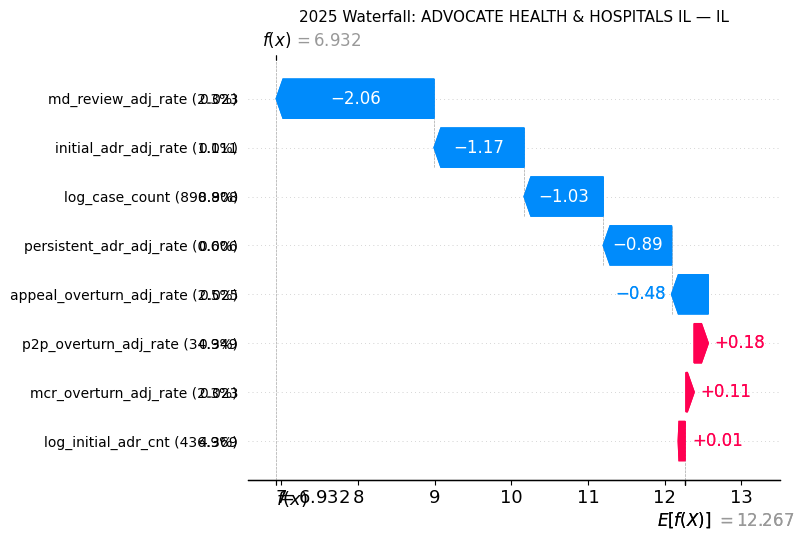

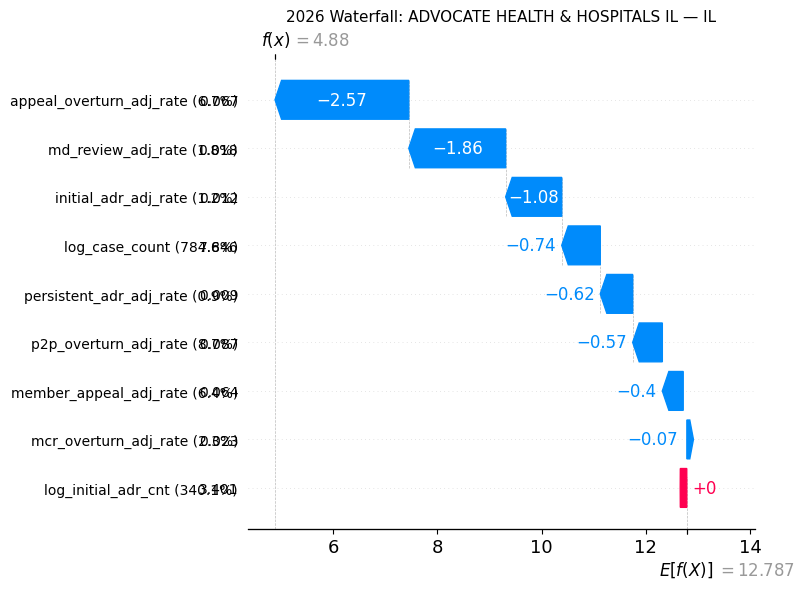

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import shap

NAVY = '#1E3477'
TARGET_HOSPITAL = 'ADVOCATE HEALTH & HOSPITALS IL'


def recolor_bars(fig):

    for ax in fig.get_axes():

        for patch in ax.patches:

            try:
                r, g, b = patch.get_facecolor()[:3]

                # recolor SHAP default blue bars
                if b > 0.5 and r < 0.4 and g < 0.5:
                    patch.set_facecolor(NAVY)

            except:
                pass


def is_gray(color):

    try:

        if isinstance(color, str):
            r, g, b = mcolors.to_rgb(color)

        else:
            r, g, b = color[:3]

        return (
            abs(r - g) < 0.05 and
            abs(g - b) < 0.05 and
            r > 0.4
        )

    except:
        return False


def relabel_yaxis(fig, df_row, features):

    axes = fig.get_axes()

    if len(axes) == 0:
        return

    main_ax = axes[0]

    labels = main_ax.get_yticklabels()
    new_labels = []

    for lbl in labels:

        raw = lbl.get_text().strip()

        feat = raw.split(' = ')[0].strip() if ' = ' in raw else raw

        if feat in features and feat in df_row.index:

            try:
                val = float(df_row[feat])
                pct = f"{val * 100:.1f}%"
                new_labels.append(f"{feat} ({pct})")

            except:
                new_labels.append(feat)

        else:
            new_labels.append(feat)

    main_ax.set_yticks(main_ax.get_yticks())

    main_ax.set_yticklabels(
        new_labels,
        fontsize=10,
        color='black'
    )

    # remove duplicate gray labels from secondary axes
    for ax in axes[1:]:

        for lbl in ax.get_yticklabels():

            if is_gray(lbl.get_color()):
                lbl.set_visible(False)


def plot_waterfall(explainer, df, features, year, max_display):

    explanation = explainer(df[features].values)
    explanation.feature_names = features

    mask = df['hospital_group'] == TARGET_HOSPITAL

    if not mask.any():
        print(f"{TARGET_HOSPITAL} not found in {year} data")
        return

    pos = np.where(mask.values)[0][0]

    row = df.iloc[pos]
    market = row['fin_market']

    shap.plots.waterfall(
        explanation[pos],
        max_display=max_display,
        show=False
    )

    fig = plt.gcf()

    recolor_bars(fig)

    relabel_yaxis(
        fig=fig,
        df_row=row,
        features=features
    )

    plt.title(
        f"{year} Waterfall: {TARGET_HOSPITAL} — {market}",
        fontsize=11
    )

    plt.tight_layout()
    plt.show()


# ============================================================
# 2025
# ============================================================

plot_waterfall(
    explainer=explainer_25,
    df=df_iso_25,
    features=iso_kpi_8,
    year=2025,
    max_display=8
)

# ============================================================
# 2026
# ============================================================

plot_waterfall(
    explainer=explainer_26,
    df=df_iso_26,
    features=iso_kpi_9,
    year=2026,
    max_display=9
)

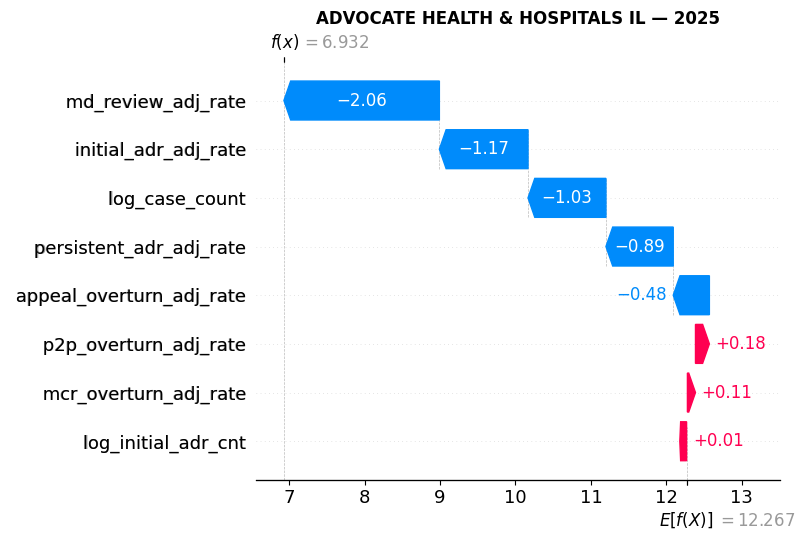

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import shap

TARGET_HOSPITAL = 'ADVOCATE HEALTH & HOSPITALS IL'
df = df_iso_25
features = iso_kpi_8
explainer = explainer_25

explanation = explainer(df[features].values)
explanation.feature_names = features

mask = df['hospital_group'] == TARGET_HOSPITAL
if mask.any():
    pos = np.where(mask.values)[0][0]
    shap.plots.waterfall(
        explanation[pos], max_display=11, show=False
    )
    ax = plt.gca()

    clean_labels = []
    for lbl in ax.get_yticklabels():
        raw = lbl.get_text()
        if ' = ' in raw:
            clean_labels.append(raw.split(' = ')[1].strip())
        else:
            clean_labels.append(raw)
    ax.set_yticks(ax.get_yticks())
    ax.set_yticklabels(clean_labels)

    for patch in ax.patches:
        fc = patch.get_facecolor()
        if fc[2] > fc[0]:
            patch.set_facecolor('#002677')

    plt.title(f"{TARGET_HOSPITAL} — 2025", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print(f"{TARGET_HOSPITAL} not found")

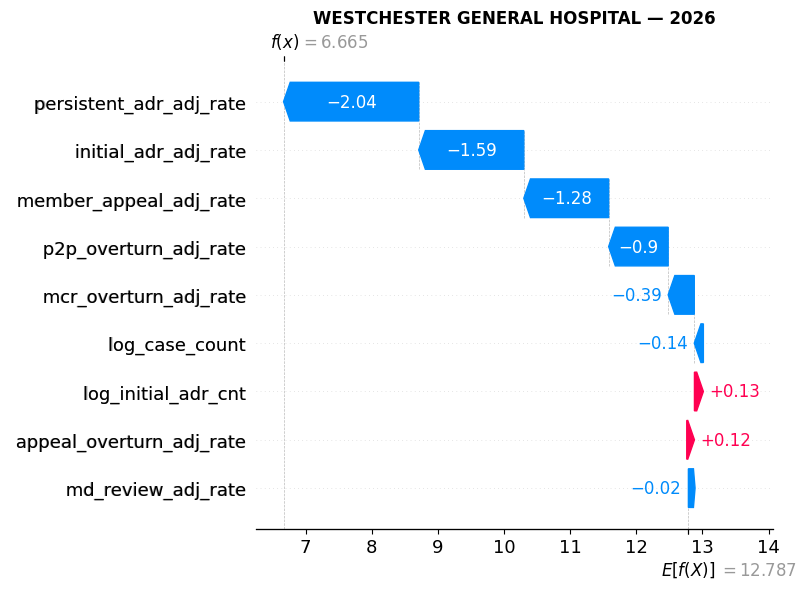

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import shap

TARGET_HOSPITAL = 'WESTCHESTER GENERAL HOSPITAL'
df = df_iso_26
features = iso_kpi_9
explainer = explainer_26

explanation = explainer(df[features].values)
explanation.feature_names = features

mask = df['hospital_group'] == TARGET_HOSPITAL
if mask.any():
    pos = np.where(mask.values)[0][0]
    shap.plots.waterfall(
        explanation[pos], max_display=11, show=False
    )
    ax = plt.gca()

    clean_labels = []
    for lbl in ax.get_yticklabels():
        raw = lbl.get_text()
        if ' = ' in raw:
            clean_labels.append(raw.split(' = ')[1].strip())
        else:
            clean_labels.append(raw)
    ax.set_yticks(ax.get_yticks())
    ax.set_yticklabels(clean_labels)

    for patch in ax.patches:
        fc = patch.get_facecolor()
        if fc[2] > fc[0]:
            patch.set_facecolor('#002677')

    plt.title(f"{TARGET_HOSPITAL} — 2026", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print(f"{TARGET_HOSPITAL} not found")

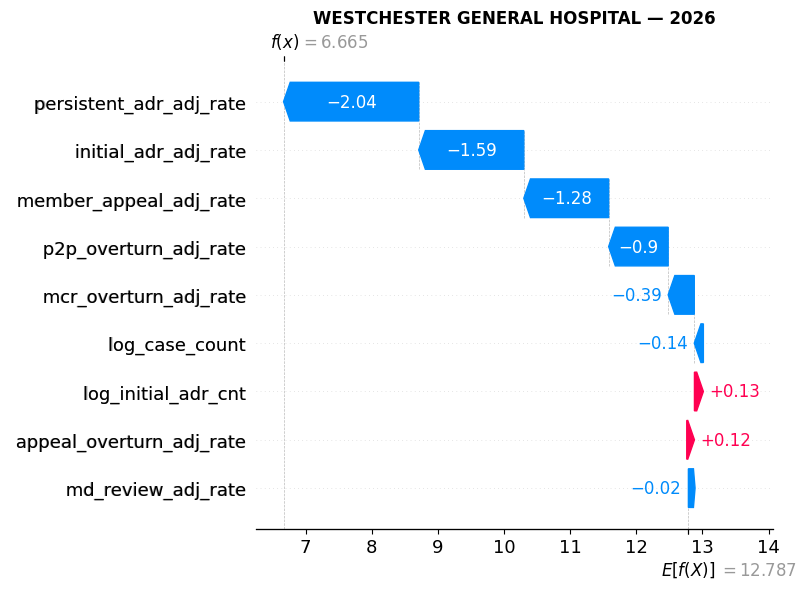

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import shap

TARGET_HOSPITAL = 'WESTCHESTER GENERAL HOSPITAL'
df = df_iso_26
features = iso_kpi_9
explainer = explainer_26

explanation = explainer(df[features].values)
explanation.feature_names = features

mask = df['hospital_group'] == TARGET_HOSPITAL

if mask.any():

    pos = np.where(mask.values)[0][0]

    shap.plots.waterfall(
        explanation[pos],
        max_display=11,
        show=False
    )

    ax = plt.gca()

    # -----------------------------------------
    # CLEAN FEATURE LABELS
    # -----------------------------------------

    clean_labels = []

    for lbl in ax.get_yticklabels():

        raw = lbl.get_text()

        if ' = ' in raw:
            clean_labels.append(raw.split(' = ')[1].strip())
        else:
            clean_labels.append(raw)

    ax.set_yticks(ax.get_yticks())
    ax.set_yticklabels(clean_labels)

    # -----------------------------------------
    # REMOVE E[f(X)] AND f(x)
    # -----------------------------------------

    for txt in ax.texts:

        t = txt.get_text()

        if 'E[f(X)]' in t or 'f(x)' in t:
            txt.set_visible(False)

    # -----------------------------------------
    # RECOLOR BLUE BARS
    # -----------------------------------------

    for patch in ax.patches:

        fc = patch.get_facecolor()

        if fc[2] > fc[0]:
            patch.set_facecolor('#002677')

    plt.title(
        f"{TARGET_HOSPITAL} — 2026",
        fontsize=12,
        fontweight='bold'
    )

    plt.tight_layout()
    plt.show()

else:

    print(f"{TARGET_HOSPITAL} not found")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import shap

TARGET_HOSPITAL = 'WESTCHESTER GENERAL HOSPITAL'

df = df_iso_26
features = iso_kpi_9
iso_model = explainer_26

X = df[features]

# =========================================================
# EXPLAIN score_samples() DIRECTLY
# =========================================================

explainer = shap.Explainer(
    iso_model.score_samples,
    X
)

shap_values = explainer(X)

# =========================================================
# TARGET HOSPITAL
# =========================================================

mask = df['hospital_group'] == TARGET_HOSPITAL

if mask.any():

    pos = np.where(mask.values)[0][0]

    row = df.iloc[pos]

    actual_score = iso_model.score_samples(
        X.iloc[[pos]]
    )[0]

    # =====================================================
    # WATERFALL
    # =====================================================

    shap.plots.waterfall(
        shap_values[pos],
        max_display=11,
        show=False
    )

    ax = plt.gca()

    # =====================================================
    # CLEAN LABELS
    # =====================================================

    clean_labels = []

    for lbl in ax.get_yticklabels():

        raw = lbl.get_text()

        if ' = ' in raw:

            feat = raw.split(' = ')[1].strip()

            if feat in row.index:

                try:

                    val = row[feat]

                    clean_labels.append(
                        f"{feat} ({val * 100:.1f}%)"
                    )

                except:
                    clean_labels.append(feat)

            else:
                clean_labels.append(feat)

        else:
            clean_labels.append(raw)

    ax.set_yticks(ax.get_yticks())
    ax.set_yticklabels(clean_labels)

    # =====================================================
    # REMOVE E[f(X)] + f(x)
    # =====================================================

    for txt in ax.texts:

        t = txt.get_text()

        if 'E[f(X)]' in t or 'f(x)' in t:
            txt.set_visible(False)

    # =====================================================
    # RECOLOR POSITIVE BARS
    # =====================================================

    for patch in ax.patches:

        fc = patch.get_facecolor()

        if fc[2] > fc[0]:
            patch.set_facecolor('#002677')

    # =====================================================
    # TITLE
    # =====================================================

    plt.title(
        f"{TARGET_HOSPITAL} — 2026\nAnomaly Score = {actual_score:.4f}",
        fontsize=12,
        fontweight='bold'
    )

    plt.tight_layout()
    plt.show()

    # =====================================================
    # VALIDATE RECONCILIATION
    # =====================================================

    shap_total = (
        shap_values[pos].base_values +
        shap_values[pos].values.sum()
    )

    print(f"Actual anomaly score : {actual_score:.6f}")
    print(f"SHAP reconstructed   : {shap_total:.6f}")

else:

    print(f"{TARGET_HOSPITAL} not found")

AttributeError: 'TreeExplainer' object has no attribute 'score_samples'

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import shap

TARGET_HOSPITAL = 'WESTCHESTER GENERAL HOSPITAL'

df = df_iso_26
features = iso_kpi_9

# IMPORTANT:
# use the ACTUAL Isolation Forest model,
# not the TreeExplainer object

iso_model = df_iso_26

X = df[features]

# =========================================================
# SHAP EXPLAINER ON score_samples()
# =========================================================

explainer = shap.Explainer(
    iso_model.score_samples,
    X
)

shap_values = explainer(X)

# =========================================================
# TARGET HOSPITAL
# =========================================================

mask = df['hospital_group'] == TARGET_HOSPITAL

if mask.any():

    pos = np.where(mask.values)[0][0]

    row = df.iloc[pos]

    actual_score = iso_model.score_samples(
        X.iloc[[pos]]
    )[0]

    # =====================================================
    # WATERFALL
    # =====================================================

    shap.plots.waterfall(
        shap_values[pos],
        max_display=11,
        show=False
    )

    ax = plt.gca()

    # =====================================================
    # CLEAN LABELS
    # =====================================================

    clean_labels = []

    for lbl in ax.get_yticklabels():

        raw = lbl.get_text()

        if ' = ' in raw:

            feat = raw.split(' = ')[1].strip()

            if feat in row.index:

                try:

                    val = row[feat]

                    clean_labels.append(
                        f"{feat} ({val * 100:.1f}%)"
                    )

                except:
                    clean_labels.append(feat)

            else:
                clean_labels.append(feat)

        else:
            clean_labels.append(raw)

    ax.set_yticks(ax.get_yticks())
    ax.set_yticklabels(clean_labels)

    # =====================================================
    # REMOVE E[f(X)] + f(x)
    # =====================================================

    for txt in ax.texts:

        t = txt.get_text()

        if 'E[f(X)]' in t or 'f(x)' in t:
            txt.set_visible(False)

    # =====================================================
    # RECOLOR BLUE BARS
    # =====================================================

    for patch in ax.patches:

        try:

            fc = patch.get_facecolor()

            if fc[2] > fc[0]:
                patch.set_facecolor('#002677')

        except:
            pass

    # =====================================================
    # TITLE
    # =====================================================

    plt.title(
        f"{TARGET_HOSPITAL} — 2026\nAnomaly Score = {actual_score:.4f}",
        fontsize=12,
        fontweight='bold'
    )

    plt.tight_layout()
    plt.show()

    # =====================================================
    # VALIDATE RECONCILIATION
    # =====================================================

    shap_total = (
        shap_values[pos].base_values +
        shap_values[pos].values.sum()
    )

    print(f"Actual anomaly score : {actual_score:.6f}")
    print(f"SHAP reconstructed   : {shap_total:.6f}")

else:

    print(f"{TARGET_HOSPITAL} not found")

AttributeError: 'DataFrame' object has no attribute 'score_samples'

In [ ]:
# You accidentally set:
# iso_model = df_iso_26
# instead of the actual Isolation Forest model

# Use your trained Isolation Forest object here
# Example names:
# iso_26_model
# if_model_26
# iso_forest_26
# etc.

# ---------------------------------------------------
# FIND YOUR ACTUAL MODEL OBJECT FIRST
# ---------------------------------------------------

type(explainer_26)
# -> shap.explainers._tree.TreeExplainer

# The model is usually stored here:
iso_model = explainer_26.model

# verify:
type(iso_model)

# should return something like:
# sklearn.ensemble._iforest.IsolationForest


# =========================================================
# FULL WORKING VERSION
# =========================================================

import numpy as np
import matplotlib.pyplot as plt
import shap

TARGET_HOSPITAL = 'WESTCHESTER GENERAL HOSPITAL'

df = df_iso_26
features = iso_kpi_9

X = df[features]

# use actual IF model
iso_model = explainer_26.model

# explain score_samples directly
explainer = shap.Explainer(
    iso_model.score_samples,
    X
)

shap_values = explainer(X)

mask = df['hospital_group'] == TARGET_HOSPITAL

if mask.any():

    pos = np.where(mask.values)[0][0]

    row = df.iloc[pos]

    actual_score = iso_model.score_samples(
        X.iloc[[pos]]
    )[0]

    shap.plots.waterfall(
        shap_values[pos],
        max_display=11,
        show=False
    )

    ax = plt.gca()

    # -----------------------------------------
    # CLEAN LABELS
    # -----------------------------------------

    clean_labels = []

    for lbl in ax.get_yticklabels():

        raw = lbl.get_text()

        if ' = ' in raw:

            feat = raw.split(' = ')[1].strip()

            if feat in row.index:

                try:

                    val = row[feat]

                    clean_labels.append(
                        f"{feat} ({val * 100:.1f}%)"
                    )

                except:
                    clean_labels.append(feat)

            else:
                clean_labels.append(feat)

        else:
            clean_labels.append(raw)

    ax.set_yticks(ax.get_yticks())
    ax.set_yticklabels(clean_labels)

    # -----------------------------------------
    # REMOVE E[f(X)] + f(x)
    # -----------------------------------------

    for txt in ax.texts:

        t = txt.get_text()

        if 'E[f(X)]' in t or 'f(x)' in t:
            txt.set_visible(False)

    # -----------------------------------------
    # RECOLOR BLUE BARS
    # -----------------------------------------

    for patch in ax.patches:

        try:

            fc = patch.get_facecolor()

            if fc[2] > fc[0]:
                patch.set_facecolor('#002677')

        except:
            pass

    plt.title(
        f"{TARGET_HOSPITAL} — 2026\nAnomaly Score = {actual_score:.4f}",
        fontsize=12,
        fontweight='bold'
    )

    plt.tight_layout()
    plt.show()

    # validate reconciliation
    shap_total = (
        shap_values[pos].base_values +
        shap_values[pos].values.sum()
    )

    print(f"Actual anomaly score : {actual_score:.6f}")
    print(f"SHAP reconstructed   : {shap_total:.6f}")

else:

    print(f"{TARGET_HOSPITAL} not found")

AttributeError: 'TreeEnsemble' object has no attribute 'score_samples'

In [1]:
# Monthly rates for flagged hospitals (md_escalation, initial_adr, persistent_adr)
flagged_hospitals = set(
    df_iso_25.query('flagged')['hospital_group'].tolist()
    + df_iso_26.query('flagged')['hospital_group'].tolist()
)

df_monthly = pd.read_sql(f"""
    select
        d.collection as hospital_group
        , a.fin_market
        , a.hce_admit_month
        , count(distinct a.case_id) as case_count
        , count(distinct case when a.icm_md_reviewed_ind = 1 then a.case_id end) as md_reviewed_cnt
        , count(distinct case when a.initialfulladr_cases = 1 then a.case_id end) as initial_adr_cnt
        , count(distinct case when a.persistentfulladr_cases = 1 then a.case_id end) as persistent_adr_cnt
    from tmp_1m.ec_avtar_25_26_3_od as a
    left join tmp_1y.tin_collection as d
        on substr(a.fa_prov_id, 2, 9) = d.tin
    where fin_brand = 'M&R'
        and (
            (ip_type in ('Medical', 'Surgical', 'Transplant')
             and to_varchar(admit_dt_act, 'MM/dd/yyyy') is not null)
            or ip_type in ('LTAC', 'SNF', 'AIR')
        )
        and loc_flag = 1
        and (
            (global_cap = 'NA' and sgr_source_name = 'COSMOS'
             and fin_product_level_3 != 'INSTITUTIONAL' and tfm_include_flag = 1)
            or (sgr_source_name = 'NICE' and nce_tadm_dec_risk_type in ('FFS', 'PHYSICIAN'))
        )
        and d.collection is not null
        and hce_admit_month between '202501' and '202604'
    group by 1, 2, 3
""", engine)

df_monthly = df_monthly[df_monthly['hospital_group'].isin(flagged_hospitals)].copy()

df_monthly['md_escalation_rate'] = df_monthly['md_reviewed_cnt'] / df_monthly['case_count']
df_monthly['initial_adr_rate'] = df_monthly['initial_adr_cnt'] / df_monthly['case_count']
df_monthly['persistent_adr_rate'] = df_monthly['persistent_adr_cnt'] / df_monthly['case_count']

total_cases = df_monthly.groupby('hospital_group')['case_count'].sum().rename('total_cases')
df_monthly = df_monthly.merge(total_cases, on='hospital_group')
df_monthly = df_monthly.sort_values(['hospital_group', 'total_cases', 'hce_admit_month'], ascending=[True, False, True])

df_monthly_out = df_monthly[[
    'hospital_group', 'fin_market', 'hce_admit_month', 'case_count',
    'md_escalation_rate', 'initial_adr_rate', 'persistent_adr_rate'
]].copy()

print(f"Flagged hospitals: {len(flagged_hospitals)} | Monthly rows: {len(df_monthly_out)}")
df_monthly_out

NameError: name 'df_iso_25' is not defined